### EDA: Time Patterns + Month/Season

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

In [2]:
load_dotenv()
engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('MYSQL_USER')}:{os.getenv('MYSQL_PASSWORD')}"
    f"@{os.getenv('MYSQL_HOST')}/{os.getenv('MYSQL_DATABASE')}"
)
os.makedirs("figures", exist_ok=True)

In [3]:
dow_query = """
SELECT day_of_week, COUNT(*) AS n_records, AVG(delay_minutes) AS avg_delay
FROM delays
GROUP BY day_of_week
ORDER BY FIELD(day_of_week,
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday');
"""
dow_delay = pd.read_sql(text(dow_query), engine)
print(dow_delay)

  day_of_week  n_records  avg_delay
0      Monday      24911   40.53840
1     Tuesday      25616   42.66127
2   Wednesday      26635   41.08384
3    Thursday      26718   44.72240
4      Friday      24402   37.74883
5    Saturday      25382   45.56977
6      Sunday      21324   42.72149


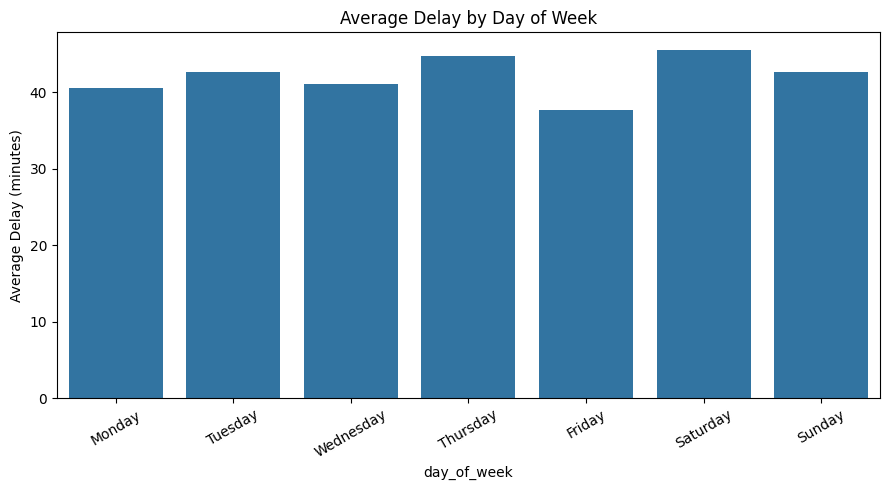

In [4]:
plt.figure(figsize=(9, 5))
sns.barplot(data=dow_delay, x="day_of_week", y="avg_delay")
plt.title("Average Delay by Day of Week")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("figures/delay_by_day_of_week.png")
plt.show()

In [5]:
time_of_day_query = """
SELECT
    CASE
        WHEN HOUR(sch.arrival_time) BETWEEN 5 AND 12 THEN 'Morning (5-12)'
        WHEN HOUR(sch.arrival_time) BETWEEN 12 AND 16 THEN 'Afternoon (12-17)'
        WHEN HOUR(sch.arrival_time) BETWEEN 16 AND 20 THEN 'Evening (17-21)'
        ELSE 'Night (21-5)'
    END AS time_of_day,
    COUNT(*) AS n_records,
    AVG(d.delay_minutes) AS avg_delay
FROM delays d
JOIN schedule sch
    ON d.train_no = sch.train_no AND d.station_no = sch.station_no
WHERE sch.arrival_time IS NOT NULL
GROUP BY time_of_day
ORDER BY avg_delay DESC;
"""
tod_delay = pd.read_sql(text(time_of_day_query), engine)
print(tod_delay)

         time_of_day  n_records  avg_delay
0  Afternoon (12-17)      30680   47.77008
1       Night (21-5)      43807   45.26416
2    Evening (17-21)      30465   43.80906
3     Morning (5-12)      62631   40.37327


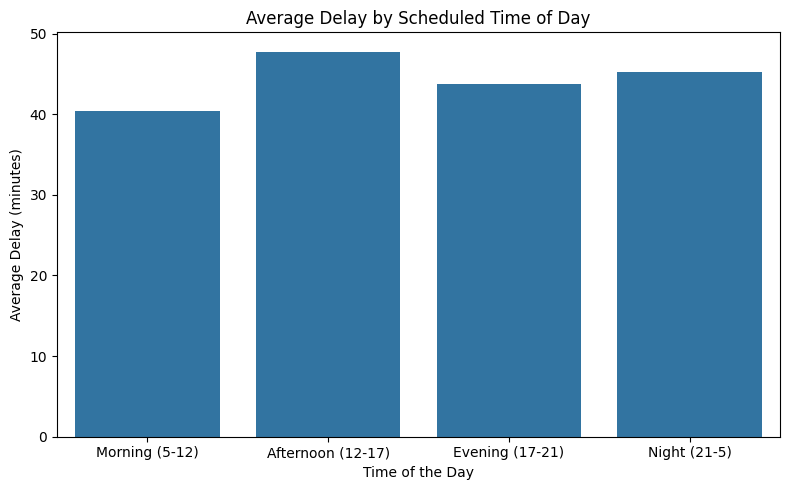

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(data=tod_delay, x="time_of_day", y="avg_delay", order=["Morning (5-12)", "Afternoon (12-17)", "Evening (17-21)", "Night (21-5)"])
plt.title("Average Delay by Scheduled Time of Day")
plt.xlabel("Time of the Day")
plt.ylabel("Average Delay (minutes)")
plt.tight_layout()
plt.savefig("figures/delay_by_time_of_day.png")
plt.show()

In [7]:
trend_query = """
SELECT
    DATE_FORMAT(`record_date`, '%Y-%m') AS `year_month`,
    COUNT(*) AS n_records,
    AVG(`delay_minutes`) AS avg_delay
FROM `delays`
GROUP BY DATE_FORMAT(`record_date`, '%Y-%m')
ORDER BY DATE_FORMAT(`record_date`, '%Y-%m');
"""
trend = pd.read_sql(text(trend_query), engine)
print(trend)

   year_month  n_records  avg_delay
0     2025-02       9996   36.61405
1     2025-03      14683   30.18225
2     2025-04      14338   30.40961
3     2025-05      14780   43.93410
4     2025-06      14023   39.72288
5     2025-07      14541   35.81349
6     2025-08      14703   49.65544
7     2025-09      14466   41.23303
8     2025-10      14898   38.40032
9     2025-11      14487   49.29944
10    2025-12      15234   44.50466
11    2026-01      15372   55.99115
12    2026-02       3467   74.06086


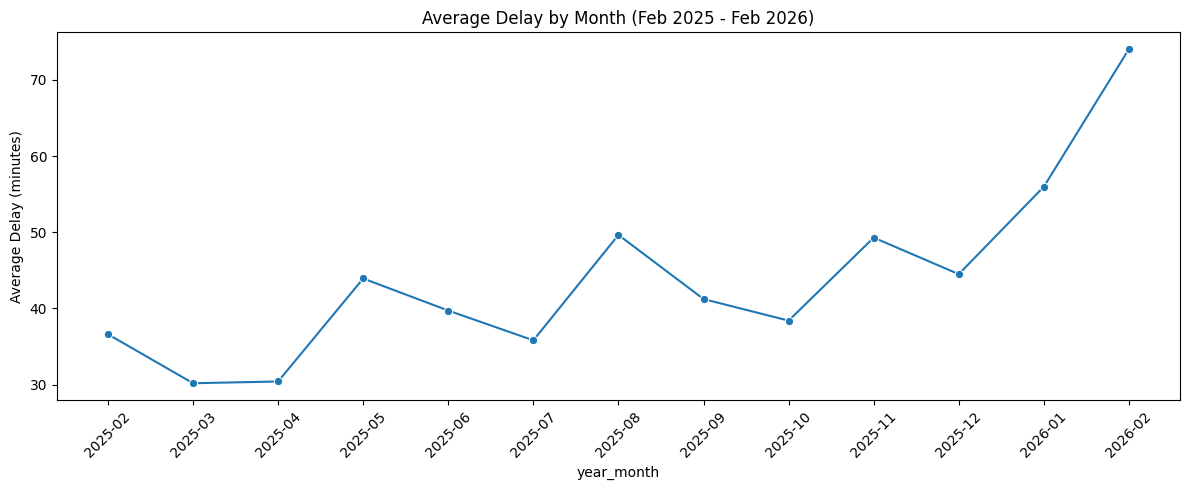

In [8]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=trend, x="year_month", y="avg_delay", marker="o")
plt.title("Average Delay by Month (Feb 2025 - Feb 2026)")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figures/delay_trend_by_month.png")
plt.show()

#### Monsoon vs non-monsoon

In [9]:
monsoon_summary_query = """
SELECT is_monsoon, COUNT(*) AS n_records,
        AVG(delay_minutes) AS avg_delay, STDDEV(delay_minutes) AS std_delay
FROM delays
GROUP BY is_monsoon;
"""
monsoon_summary = pd.read_sql(text(monsoon_summary_query), engine)
print(monsoon_summary)

   is_monsoon  n_records  avg_delay  std_delay
0           0     117255   42.43961  49.451609
1           1      57733   41.64618  51.328963


In [10]:
monsoon_raw_query = "SELECT is_monsoon, delay_minutes FROM delays;"
monsoon_raw = pd.read_sql(text(monsoon_raw_query), engine)

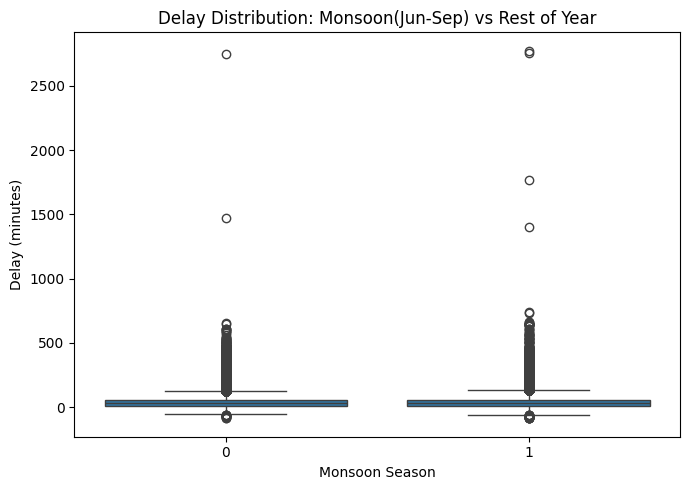

In [11]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=monsoon_raw, x="is_monsoon", y="delay_minutes")
plt.title("Delay Distribution: Monsoon(Jun-Sep) vs Rest of Year")
plt.xlabel("Monsoon Season")
plt.ylabel("Delay (minutes)")
plt.tight_layout()
# plt.savefig("figures/delay_monsoon_vs_rest.png")
plt.show()

## Summary
Day of week: Saturdays stand out with higher delays.

Time of day: Afternoons are worst, mornings best.

Seasonality: Monsoon months (Jun–Sep) show a visible spike above the rest of the year.